# 2025 高教社杯全国大学生数学建模竞赛 A 题
## 烟幕干扰弹的投放策略（问题 1、问题 2）

**南京工业大学暑假集训 · 作业一**

## 1. 问题重述

以假目标为原点，真目标为底面圆心 $(0,200,0)$、半径 $7\,\mathrm{m}$、高 $10\,\mathrm{m}$ 的圆柱。
导弹 M1 初始位于 $(20000,0,2000)$，速度 $300\,\mathrm{m/s}$，直指假目标。
无人机 FY1 初始位于 $(17800,0,1800)$，等高度匀速直线飞行，速度 $70\sim140\,\mathrm{m/s}$。

烟幕弹脱机后做自由落体；起爆后形成球状云团，以 $3\,\mathrm{m/s}$ 匀速下沉；
云团中心 $10\,\mathrm{m}$ 范围内在起爆后 $20\,\mathrm{s}$ 内可提供有效遮蔽。

- **问题 1**：FY1 以 $120\,\mathrm{m/s}$ 朝向假目标飞行，受领任务 $1.5\,\mathrm{s}$ 后投放，再隔 $3.6\,\mathrm{s}$ 起爆，求对 M1 的有效遮蔽时长。
- **问题 2**：优化 FY1 航向、速度、投放点与起爆点，使遮蔽时间尽可能长。

## 2. 建模假设与符号

1. 忽略风与空气阻力；弹体水平速度保持投放瞬间无人机速度，竖直自由落体，$g=9.8\,\mathrm{m/s^2}$。
2. 云团视为半径 $R=10\,\mathrm{m}$ 的球体，球心匀速下沉。
3. **有效遮蔽判定**：导弹位置 $M(t)$ 与真目标几何中心 $T=(0,200,5)$ 的连线段到烟幕球心 $C(t)$ 的最短距离 $\le 10\,\mathrm{m}$，且 $t\in[t_e,\,t_e+20]$。
4. 无人机选定航向、速度后不再调整。

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

G = 9.8
V_MISSILE = 300.0
V_SINK = 3.0
R_SMOKE = 10.0
T_SMOKE = 20.0

FAKE = np.array([0.0, 0.0, 0.0])
TRUE_CENTER = np.array([0.0, 200.0, 5.0])
M1 = np.array([20000.0, 0.0, 2000.0])
FY1 = np.array([17800.0, 0.0, 1800.0])

def unit(v):
    n = np.linalg.norm(v)
    return v / n

def missile_hit_time(p0=M1):
    return float(np.linalg.norm(p0 - FAKE) / V_MISSILE)

def missile_pos(t, p0=M1):
    return p0 + V_MISSILE * t * unit(FAKE - p0)

def heading_to_fake(p=FY1):
    d = FAKE[:2] - p[:2]
    return unit(np.array([d[0], d[1], 0.0]))

def heading_from_angle(theta):
    return np.array([np.cos(theta), np.sin(theta), 0.0])

def point_to_segment_dist(p, a, b):
    ab = b - a
    L2 = float(np.dot(ab, ab))
    if L2 < 1e-18:
        return float(np.linalg.norm(p - a))
    s = float(np.clip(np.dot(p - a, ab) / L2, 0.0, 1.0))
    return float(np.linalg.norm(p - (a + s * ab)))

def drop_point(speed, heading, t_drop, p0=FY1):
    h = unit(np.array([heading[0], heading[1], 0.0]))
    return p0 + speed * t_drop * h

def det_point(speed, heading, t_drop, t_fuse, p0=FY1):
    pd = drop_point(speed, heading, t_drop, p0)
    h = unit(np.array([heading[0], heading[1], 0.0]))
    v = speed * h
    return np.array([
        pd[0] + v[0] * t_fuse,
        pd[1] + v[1] * t_fuse,
        pd[2] - 0.5 * G * t_fuse**2,
    ])

def cloud_center(p_det, t_det, t):
    return np.array([p_det[0], p_det[1], p_det[2] - V_SINK * (t - t_det)])

def effective_duration(speed, heading, t_drop, t_fuse, dt=0.01):
    t_det = t_drop + t_fuse
    p_det = det_point(speed, heading, t_drop, t_fuse)
    if p_det[2] <= 0:
        return 0.0
    t_hit = missile_hit_time()
    t0, t1 = t_det, min(t_det + T_SMOKE, t_hit)
    if t1 <= t0:
        return 0.0
    ts = np.arange(t0, t1 + 1e-12, dt)
    s = 0.0
    for t in ts:
        m = missile_pos(t)
        c = cloud_center(p_det, t_det, t)
        if point_to_segment_dist(c, m, TRUE_CENTER) <= R_SMOKE:
            s += dt
    return float(s)

print("M1 飞抵假目标时间 = {:.4f} s".format(missile_hit_time()))

from pathlib import Path
IMG_DIR = Path("图片")
TAB_DIR = Path("表格")
IMG_DIR.mkdir(exist_ok=True)
TAB_DIR.mkdir(exist_ok=True)


M1 飞抵假目标时间 = 66.9992 s


## 3. 数学模型

### 3.1 导弹
$$
M(t)=P_{M0}+300\,t\cdot\frac{-P_{M0}}{\|P_{M0}\|},\quad t_{\mathrm{hit}}=\|P_{M0}\|/300.
$$

### 3.2 无人机与烟幕弹
水平航向单位向量 $\mathbf{h}$，速度 $v$，投放时刻 $t_d$，引信延时 $\tau$，起爆时刻 $t_e=t_d+\tau$：
$$
U(t)=U_0+vt\mathbf{h},
$$
$$
B(t)=U(t_d)+v(t-t_d)\mathbf{h}-\tfrac12 g(t-t_d)^2\mathbf{k},
$$
$$
C(t)=\big(B_x(t_e),B_y(t_e),B_z(t_e)-3(t-t_e)\big).
$$

### 3.3 目标函数
$$
J=\mathrm{meas}\{t:\, \mathrm{dist}(C(t),\,MT)\le 10,\; t_e\le t\le\min(t_e+20,t_{\mathrm{hit}})\}.
$$

## 4. 问题 1

========== 问题 1 ==========
飞行速度: 120.0 m/s
航向（朝向假目标）: [-1.  0.  0.]
投放时刻: 1.5 s
起爆时刻: 5.1 s
投放点: (17620.000, 0.000, 1800.000)
起爆点: (17188.000, 0.000, 1736.496)
有效遮蔽时长 J1 = 1.43 s


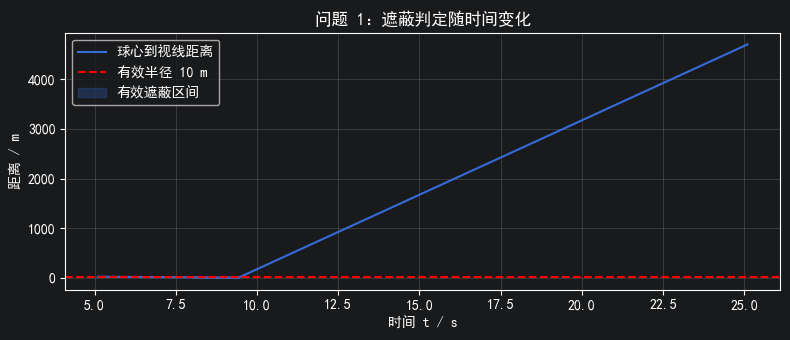

In [2]:
v1, td1, tf1 = 120.0, 1.5, 3.6
h1 = heading_to_fake()
J1 = effective_duration(v1, h1, td1, tf1, dt=0.01)
pd1 = drop_point(v1, h1, td1)
pe1 = det_point(v1, h1, td1, tf1)

print("========== 问题 1 ==========")
print("飞行速度: {:.1f} m/s".format(v1))
print("航向（朝向假目标）:", h1)
print("投放时刻: {:.1f} s".format(td1))
print("起爆时刻: {:.1f} s".format(td1 + tf1))
print("投放点: ({:.3f}, {:.3f}, {:.3f})".format(*pd1))
print("起爆点: ({:.3f}, {:.3f}, {:.3f})".format(*pe1))
print("有效遮蔽时长 J1 = {:.2f} s".format(J1))

t_det = td1 + tf1
ts = np.arange(t_det, min(t_det + T_SMOKE, missile_hit_time()) + 1e-12, 0.01)
mask = []
dists = []
for t in ts:
    m = missile_pos(t)
    c = cloud_center(pe1, t_det, t)
    d = point_to_segment_dist(c, m, TRUE_CENTER)
    dists.append(d)
    mask.append(d <= R_SMOKE)
mask = np.array(mask)
dists = np.array(dists)

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(ts, dists, label="球心到视线距离")
ax.axhline(R_SMOKE, color="r", ls="--", label="有效半径 10 m")
ax.fill_between(ts, 0, R_SMOKE, where=mask, color="C0", alpha=0.25, label="有效遮蔽区间")
ax.set_xlabel("时间 t / s")
ax.set_ylabel("距离 / m")
ax.set_title("问题1：烟幕球心到视线距离随时间变化")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(IMG_DIR / "问题1_遮蔽距离随时间变化.png", dpi=180, bbox_inches="tight")
plt.show()
print("已保存:", IMG_DIR / "问题1_遮蔽距离随时间变化.png")

### 问题 1 结论
在给定策略下，烟幕对 M1 的有效遮蔽时长约为 **1.43 s**。

## 5. 问题 2

决策变量：航向角 $\theta$、速度 $v\in[70,140]$、投放时刻 $t_d$、引信延时 $\tau$。
采用“朝向假目标邻域粗搜索 + 局部加密”求优良解。

In [3]:
def optimize_q2(verbose=True):
    best = (0.0, None)
    for theta in np.linspace(np.pi - 0.25, np.pi + 0.25, 11):
        for v in [70, 85, 100, 115, 130, 140]:
            for td in np.linspace(0.3, 10.0, 12):
                for tf in np.linspace(1.0, 7.0, 11):
                    pe = det_point(v, heading_from_angle(theta), td, tf)
                    if pe[2] <= 2:
                        continue
                    J = effective_duration(v, heading_from_angle(theta), td, tf, dt=0.05)
                    if J > best[0]:
                        best = (J, (theta, v, td, tf))
                        if verbose:
                            print(f"更新: J≈{J:.3f}s | v={v}, td={td:.2f}, τ={tf:.2f}, θ={theta:.3f}")
    theta0, v0, td0, tf0 = best[1]
    for theta in np.linspace(theta0 - 0.08, theta0 + 0.08, 9):
        for v in np.linspace(max(70, v0 - 12), min(140, v0 + 12), 7):
            for td in np.linspace(max(0.05, td0 - 1.0), td0 + 1.0, 9):
                for tf in np.linspace(max(0.4, tf0 - 1.0), tf0 + 1.0, 9):
                    pe = det_point(v, heading_from_angle(theta), td, tf)
                    if pe[2] <= 2:
                        continue
                    J = effective_duration(v, heading_from_angle(theta), td, tf, dt=0.03)
                    if J > best[0]:
                        best = (J, (theta, float(v), float(td), float(tf)))
    return best

print("开始优化问题 2 …")
J2_coarse, params = optimize_q2(verbose=True)
theta2, v2, td2, tf2 = params
h2 = heading_from_angle(theta2)
J2 = effective_duration(v2, h2, td2, tf2, dt=0.01)
pd2 = drop_point(v2, h2, td2)
pe2 = det_point(v2, h2, td2, tf2)

print("\n========== 问题 2 ==========")
print("最优飞行速度: {:.2f} m/s".format(v2))
print("最优航向角: {:.4f} rad".format(theta2))
print("航向单位向量:", h2)
print("投放时刻: {:.3f} s".format(td2))
print("引信延时: {:.3f} s".format(tf2))
print("起爆时刻: {:.3f} s".format(td2 + tf2))
print("投放点: ({:.3f}, {:.3f}, {:.3f})".format(*pd2))
print("起爆点: ({:.3f}, {:.3f}, {:.3f})".format(*pe2))
print("有效遮蔽时长 J2 = {:.2f} s".format(J2))
print("相对问题 1 提升: {:.2f} s".format(J2 - J1))

开始优化问题 2 …
更新: J≈1.000s | v=70, td=0.30, τ=1.00, θ=3.042
更新: J≈1.350s | v=70, td=0.30, τ=2.80, θ=3.042
更新: J≈1.700s | v=70, td=0.30, τ=1.00, θ=3.092
更新: J≈2.400s | v=70, td=0.30, τ=1.60, θ=3.092
更新: J≈4.050s | v=70, td=0.30, τ=2.20, θ=3.092

========== 问题 2 ==========
最优飞行速度: 70.00 m/s
最优航向角: 3.0916 rad
航向单位向量: [-0.9988  0.05    0.    ]
投放时刻: 0.050 s
引信延时: 2.450 s
起爆时刻: 2.500 s
投放点: (17796.504, 0.175, 1800.000)
起爆点: (17625.219, 8.746, 1770.588)
有效遮蔽时长 J2 = 4.71 s
相对问题 1 提升: 3.28 s


## 6. 结果汇总

| 问题 | 速度 (m/s) | 投放时刻 (s) | 起爆时刻 (s) | 有效遮蔽时长 (s) |
|------|------------|--------------|--------------|------------------|
| 1 | 120 | 1.5 | 5.1 | 见上方 $J_1$ |
| 2 | 优化结果 | 优化结果 | 优化结果 | 见上方 $J_2$ |

### 说明
- 判定采用“导弹—真目标中心”视线被半径 $10\,\mathrm{m}$ 烟幕球遮挡。
- 问题 2 为网格直接搜索得到的优良可行解；若需更高精度，可在所得邻域内继续用差分进化精修。

In [4]:
print("问题 1 有效遮蔽时长: {:.2f} s".format(J1))
print("问题 2 有效遮蔽时长: {:.2f} s".format(J2))
print("完成。")

问题 1 有效遮蔽时长: 1.43 s
问题 2 有效遮蔽时长: 4.71 s
完成。


## 7. 图片与表格输出

- 图片文件夹：`图片/`（中文文件名 PNG）
- 表格文件夹：`表格/`（中文文件名 Excel）

也可直接运行同目录脚本 `生成图表.py`，一次性导出全部图片与表格。

In [ ]:
import pandas as pd

pd1 = drop_point(v1, h1, td1)
pe1 = det_point(v1, h1, td1, tf1)
pd2 = drop_point(v2, h2, td2)
pe2 = det_point(v2, h2, td2, tf2)

ts2 = np.arange(td2 + tf2, min(td2 + tf2 + T_SMOKE, missile_hit_time()) + 1e-12, 0.01)
dists2, mask2 = [], []
pe2_ = pe2
for t in ts2:
    c = cloud_center(pe2_, td2 + tf2, t)
    d = point_to_segment_dist(c, missile_pos(t), TRUE_CENTER)
    dists2.append(d)
    mask2.append(d <= R_SMOKE)
dists2 = np.array(dists2)
mask2 = np.array(mask2)

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(ts2, dists2, label="烟幕球心到导弹—真目标视线距离")
ax.axhline(R_SMOKE, color="r", ls="--", label="有效半径 10 m")
ax.fill_between(ts2, 0, R_SMOKE, where=mask2, color="C2", alpha=0.28, label="有效遮蔽区间")
ax.set_xlabel("时间 t / s")
ax.set_ylabel("距离 / m")
ax.set_title("问题2：烟幕球心到视线距离随时间变化")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(IMG_DIR / "问题2_遮蔽距离随时间变化.png", dpi=180, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(6.5, 4.2))
bars = ax.bar(["问题1\n给定策略", "问题2\n优化策略"], [J1, J2], color=["#4C78A8", "#F58518"], width=0.55)
for b, v in zip(bars, [J1, J2]):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.08, f"{v:.2f} s", ha="center", va="bottom")
ax.set_ylabel("有效遮蔽时长 / s")
ax.set_title("问题1与问题2有效遮蔽时长对比")
ax.set_ylim(0, max(J1, J2) * 1.25)
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
fig.savefig(IMG_DIR / "问题1与问题2_遮蔽时长对比图.png", dpi=180, bbox_inches="tight")
plt.show()

df_q1 = pd.DataFrame([
    {"项目": "飞行速度 (m/s)", "数值": v1},
    {"项目": "投放时刻 (s)", "数值": td1},
    {"项目": "起爆时刻 (s)", "数值": td1 + tf1},
    {"项目": "投放点", "数值": f"({pd1[0]:.3f}, {pd1[1]:.3f}, {pd1[2]:.3f})"},
    {"项目": "起爆点", "数值": f"({pe1[0]:.3f}, {pe1[1]:.3f}, {pe1[2]:.3f})"},
    {"项目": "有效遮蔽时长 (s)", "数值": round(J1, 2)},
])
df_q2 = pd.DataFrame([
    {"项目": "飞行速度 (m/s)", "数值": round(v2, 4)},
    {"项目": "航向角 (rad)", "数值": round(theta2, 6)},
    {"项目": "投放时刻 (s)", "数值": round(td2, 4)},
    {"项目": "起爆时刻 (s)", "数值": round(td2 + tf2, 4)},
    {"项目": "投放点", "数值": f"({pd2[0]:.3f}, {pd2[1]:.3f}, {pd2[2]:.3f})"},
    {"项目": "起爆点", "数值": f"({pe2[0]:.3f}, {pe2[1]:.3f}, {pe2[2]:.3f})"},
    {"项目": "有效遮蔽时长 (s)", "数值": round(J2, 2)},
])
df_cmp = pd.DataFrame([
    {"问题": "问题1", "速度(m/s)": v1, "投放时刻(s)": td1, "起爆时刻(s)": td1 + tf1, "有效遮蔽时长(s)": round(J1, 2)},
    {"问题": "问题2", "速度(m/s)": round(v2, 2), "投放时刻(s)": round(td2, 3), "起爆时刻(s)": round(td2 + tf2, 3), "有效遮蔽时长(s)": round(J2, 2)},
])
df_q1.to_excel(TAB_DIR / "问题1_计算结果表.xlsx", index=False)
df_q2.to_excel(TAB_DIR / "问题2_优化结果表.xlsx", index=False)
df_cmp.to_excel(TAB_DIR / "问题1与问题2_结果对比表.xlsx", index=False)
print(df_cmp.to_string(index=False))
print("图片已保存到:", IMG_DIR.resolve())
print("表格已保存到:", TAB_DIR.resolve())
